# NB03a — Multispectral Band Clipping

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `03a_bda_MS_Clipping_v30.ipynb` |
| **Version** | v30 |
| **Pipeline position** | Processing. After NB02b (MS download), before NB03d (derived products). |
| **Last validated** | 2026-04-XX |

## Narrative

Extracts individual spectral bands from downloaded Sentinel-2 L2A zip archives,
clips them to each city's `aoi_bbox`, and saves as per-band GeoTIFFs. This is the
bridge between raw S2 downloads (NB02b) and derived multispectral products (NB03d).

The notebook reads `nb02a_scene_plan.json` to determine which scenes need processing,
extracts band JP2s from the zip to a temp directory, clips each band to the city's
`aoi_bbox` from AOI.geojson, saves as `s2__{band}__{YYYYMMDD}.tif`, then deletes
the temp extraction. Skip-if-exists logic prevents reprocessing.

All 13 bands are extracted: 4 at 10m (B02-B04, B08), 7 at 20m (B05-B07, B8A, B11,
B12, SCL), and 2 at 60m (B01, B09). The SCL (Scene Classification Layer) band is
critical for cloud masking in downstream composites and DL patch generation.

An optional polygon mask cell exists but is disabled by default — all clipping uses
rectangular `aoi_bbox` to maintain consistent raster grids across all products.

## Scientific Rationale
Sentinel-2 multispectral bands provide complementary information to SAR: visible bands
capture structural damage and debris, NIR/SWIR bands detect vegetation loss and burn
scars, and spectral indices (NDVI, NBR, NDBI) quantify land cover change. Per-band
extraction preserves the native resolution of each band (10m/20m/60m) for downstream
composite generation and index computation in NB03d.

The SCL band from L2A processing enables cloud/shadow masking which is essential for
creating cloud-free composites and for excluding cloudy patches in DL training (NB09d).

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `nb02a_scene_plan.json` | NB02a | JSON (MS scene list per city) |
| S2 L2A zip files | `MS_ZIP_DIR/` (NB02b) | Zip archives (~1 GB each) |
| `AOI.geojson` per city | NB01b | GeoJSON (aoi_bbox for clipping) |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| Per-band GeoTIFFs | `MS_DIR/{city}/s2__{band}__{YYYYMMDD}.tif` | NB03d (composites, indices) |
| Updated `nb02a_scene_plan.json` | `OUTPUTS_DIR/` | Status tracking |
| `bda.sqlite` (ms_products) | `CATALOG_DB` | NB05 |

## Prerequisites
- NB02b must have run (MS zips downloaded)
- NB01b must have run (AOI.geojson per city)
- NB02a must have run (plan exists)

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| All 13 bands extracted | Preserve full spectral range for index computation | Flexibility |
| aoi_bbox clip (not polygon) | Rectangular grid alignment across all products | Architecture principle |
| Per-band TIFs (not stacked) | Each band has different native resolution | S2 product structure |
| Flat directory (no period subdirs) | Period derived at runtime from dates vs battle metadata | Architecture principle |
| Naming: `s2__{band}__{YYYYMMDD}.tif` | Double-underscore convention | Pipeline standard |
| Skip-if-exists | Prevent reprocessing on reruns | Efficiency |
| POLYGON_MASK_ENABLED=False | Optional, disabled by default | Consistency |

## Known Limitations
- 60m bands (B01, B09) are resampled to 10m during clip — may introduce artifacts
- Cloud-heavy scenes are clipped regardless — cloud masking is downstream (NB03d/NB09d)
- Large cities (Mariupol) may produce 500+ TIFs across all dates and bands

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1 | Cell 3 | Config (BANDS, CLIP_BANDS, BOUNDARY_BUFFER) | Config |
| 2 | Cell 4 | Load global_setup | Config |
| 3-4 | Cell MS-CLIP | Extract + clip bands to aoi_bbox | **Core** |
| 5-6 | Cell POLYGON-MASK | Optional polygon mask (disabled) | Optional |
| 7-8 | Cell 14D-VERIFY | Product completeness check | QA |
| 9 | Cell SQLITE | Register MS products in bda.sqlite | **Core** |
| 10 | Cell SUMMARY | Completion report | QA |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.3 Preprocessing — Multispectral | MS-CLIP | Band extraction, clipping strategy |
| 3.3 Preprocessing — Quality Control | 14D-VERIFY | Product completeness verification |

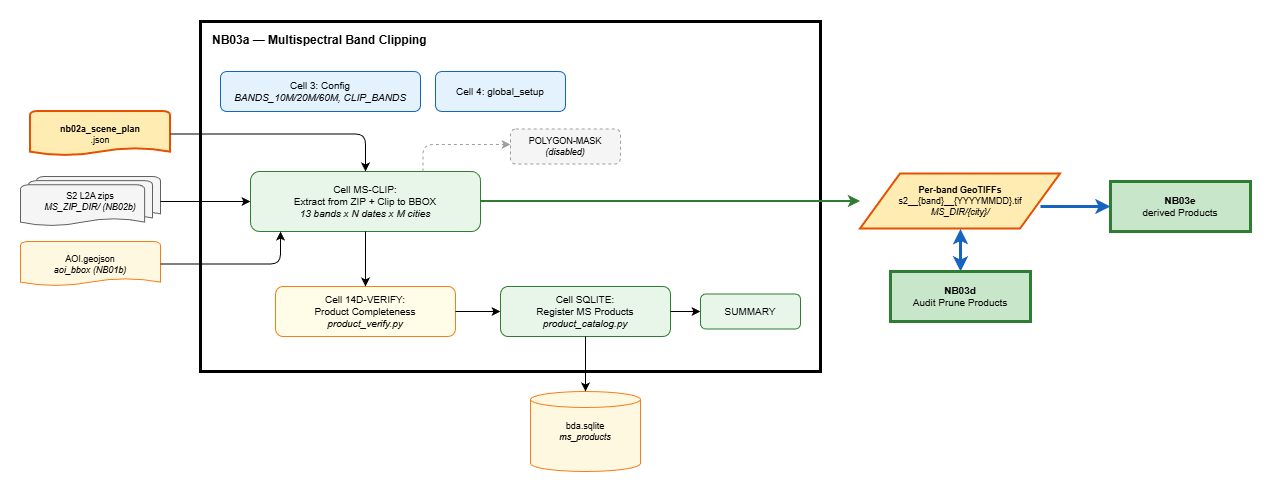

In [1]:
# @title CELL 3: NB03a CONFIG
TIER_SELECTION = [0, 1, 2,3,4,5]
CITY_SELECTION = None          # or ["Mariupol"]
BANDS_10M = ['B02', 'B03', 'B04', 'B08']
BANDS_20M = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12', 'SCL']
BANDS_60M = ['B01', 'B09']
ALL_BANDS = BANDS_10M + BANDS_20M + BANDS_60M
CLIP_BANDS = ALL_BANDS
BOUNDARY_BUFFER_DEG = 0.01
CLIP_BY_POLYGON = False

In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

BDA GLOBAL SETUP
Started: 2026-04-09 21:48:24
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2, 3, 4, 5]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 50 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:532: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     912.4/7452.0 GB (6539.7 GB free)
  GDrive (F:)     967.6/3726.0 GB (2758.4 GB free)
  Local data      12044.4/14901.9 GB (2857.5 GB free)
  Data stack      967.6/3726.0 GB (2758.4 GB free)
  WSL ext4        143.0/1006.9 GB (812.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 50, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_b

# MS BAND CLIPPING (PLAN-BASED)

In [3]:
# @title CELL MS-CLIP: CLIP MULTISPECTRAL BANDS TO AOI BBOX (PLAN-BASED)
# =============================================================================
# Extracts bands from downloaded S2 zips, clips to city aoi_bbox,
# saves as per-band GeoTIFFs.
#
# Input:  MS_ZIP_DIR/*.zip (extracted to temp, clipped, temp deleted)
# Output: MS_DIR/{city}/s2__{band}__{YYYYMMDD}.tif (flat, no period subdirs)
#
# Task source: nb02a_scene_plan.json (ms entries with scene_name)
# =============================================================================

import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds
from rasterio.mask import mask as rasterio_mask
from pathlib import Path
from datetime import datetime
import geopandas as gpd
from shapely.geometry import mapping
import json
import re
import shutil
import time
import gc
import zipfile
import warnings
warnings.filterwarnings('ignore')

FORCE_RERUN = False
DRY_RUN = False

EXCLUDED_FOLDERS = ['temp', 'tmp', 'cache', 'metadata', 'scenes', 'composites', 'rgb', 'cloud_masks']

print("=" * 80)
print("NB03a MS-CLIP: CLIP MULTISPECTRAL BANDS (PLAN-BASED)")
print("=" * 80)
print(f"  Timestamp:  {datetime.now().isoformat()}")
print(f"  MS root:    {MS_DIR}")
print(f"  Bands:      {CLIP_BANDS}")
print(f"  Dry run:    {DRY_RUN}")

# =============================================================================
# SAFE BAND EXTRACTION (proven from v28)
# =============================================================================

def extract_date_from_safe(safe_name):
    match = re.search(r'_(\d{8})T', safe_name)
    if match:
        return match.group(1)
    return None

def find_band_in_safe(safe_dir, band):
    if band in BANDS_10M:
        res = '10m'
    elif band in BANDS_60M:
        res = '60m'
    else:
        res = '20m'

    pattern_jp2 = f"*_{band}_{res}.jp2"
    pattern_tif = f"*_{band}_{res}.tif"

    matches = list(safe_dir.rglob(pattern_jp2))
    if not matches:
        matches = list(safe_dir.rglob(pattern_tif))
    if not matches:
        matches = list(safe_dir.rglob(f"*_{band}.jp2")) + list(safe_dir.rglob(f"*_{band}.tif"))

    if matches:
        img_data = [m for m in matches if 'IMG_DATA' in str(m)]
        return img_data[0] if img_data else matches[0]
    return None

# =============================================================================
# CLIP BAND TO CITY BOUNDARY (proven from v28)
# =============================================================================

def clip_band_to_city(band_path, city_geom, output_path, band_name):
    with rasterio.open(band_path) as src:
        src_crs = src.crs
        src_epsg = src_crs.to_epsg()
        if src_epsg and src_epsg != 4326:
            city_gdf = gpd.GeoDataFrame(geometry=[city_geom], crs='EPSG:4326')
            city_gdf = city_gdf.to_crs(src_crs)
        elif not src_epsg:
            city_gdf = gpd.GeoDataFrame(geometry=[city_geom], crs='EPSG:4326')
            city_gdf = city_gdf.to_crs(src_crs)
        else:
            city_gdf = gpd.GeoDataFrame(geometry=[city_geom], crs='EPSG:4326')

        buffered_geom = city_gdf.geometry.iloc[0]
        try:
            clipped, clipped_transform = rasterio_mask(
                src, [mapping(buffered_geom)], crop=True, nodata=0
            )
        except Exception as e:
            print(f"        Clip failed ({e})")
            return False

        out_meta = src.meta.copy()
        out_meta.update({
            'driver': 'GTiff',
            'height': clipped.shape[1],
            'width': clipped.shape[2],
            'transform': clipped_transform,
            'compress': 'lzw',
            'nodata': 0,
        })

        output_path.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(output_path, 'w', **out_meta) as dst:
            dst.write(clipped)

    return True

# =============================================================================
# CHECK EXISTING CLIPPED TIFS (proven from v28)
# =============================================================================

def check_existing_tifs(city, date_str, output_dir):
    existing_bands = set()
    if not output_dir.exists():
        return existing_bands
    for f in output_dir.iterdir():
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        new_match = re.match(r'^s2__([a-z0-9]+)__' + re.escape(date_str) + r'\.tif$', f.name)
        if new_match:
            existing_bands.add(new_match.group(1).upper())
        elif f"_S2_{date_str}_" in f.name:
            band_match = re.search(r'_(B\d{2}|B8A|SCL)_', f.name)
            if band_match:
                existing_bands.add(band_match.group(1))
    return existing_bands

# =============================================================================
# ZIP LOOKUP (proven from v28)
# =============================================================================

def find_ms_zip(scene_name):
    base = scene_name.replace('.SAFE', '')
    zip_path = MS_ZIP_DIR / f"{base}.zip"
    if zip_path.exists():
        return zip_path
    tile_match = re.search(r'_(T\d{2}[A-Z]{3})_', base)
    if tile_match:
        tile_id = tile_match.group(1)
        date_match = re.search(r'_(\d{8})T', base)
        if date_match:
            date_part = date_match.group(1)
            candidates = [p for p in MS_ZIP_DIR.glob(f"*_{date_part}T*_{tile_id}_*.zip")]
            if candidates:
                return max(candidates, key=lambda p: p.stat().st_size)
    prefix = base[:40]
    candidates = list(MS_ZIP_DIR.glob(f"{prefix}*.zip"))
    if candidates:
        return max(candidates, key=lambda p: p.stat().st_size)
    return None

# =============================================================================
# BUILD TASKS FROM PLAN (NEW: replaces metadata JSON discovery)
# =============================================================================

MS_TEMP_DIR.mkdir(parents=True, exist_ok=True)

print("\n--- Building tasks from scene plan ---\n")

PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'
if not PLAN_FILE.exists():
    raise FileNotFoundError(f"Scene plan not found: {PLAN_FILE}\nRun NB02a first.")

with open(PLAN_FILE) as f:
    PLAN = json.load(f)

# load clip geometries
city_geoms = {}
if CITIES_DIR.exists():
    for city_dir in sorted(CITIES_DIR.iterdir()):
        if not city_dir.is_dir():
            continue
        try:
            city_geoms[city_dir.name] = load_aoi_bbox(city_dir.name, CITIES_DIR)
        except (FileNotFoundError, ValueError):
            pass

print(f"  Loaded {len(city_geoms)} city clip geometries (mode: bbox)")

city_tasks = []

for city_name, plan in PLAN.items():
    tier = plan.get('tier', 99)
    if TIER_SELECTION and tier not in TIER_SELECTION:
        continue
    if CITY_SELECTION and city_name not in CITY_SELECTION:
        continue
    if city_name not in city_geoms:
        continue

    for entry in plan.get('ms', []):
        scene_name = entry.get('scene_name', '')
        if not scene_name:
            continue

        date_str = extract_date_from_safe(scene_name)
        if not date_str:
            date_raw = entry.get('date', '').replace('-', '')
            if len(date_raw) == 10:
                date_str = date_raw.replace('-', '')
            elif len(date_raw) == 8:
                date_str = date_raw
            else:
                continue

        zip_path = find_ms_zip(scene_name)
        if zip_path is None:
            continue

        city_tasks.append({
            'city': city_name,
            'period': entry.get('period', ''),
            'scene_name': scene_name,
            'date_str': date_str,
            'zip_path': zip_path,
            'plan_entry': entry,
        })

print(f"  Scene-tasks with zips on disk: {len(city_tasks)}")

city_period_counts = {}
for t in city_tasks:
    key = t['city']
    if key not in city_period_counts:
        city_period_counts[key] = {}
    p = t['period']
    city_period_counts[key][p] = city_period_counts[key].get(p, 0) + 1

print("\n  City overview:")
for city in sorted(city_period_counts.keys()):
    parts = [f"{p}={n}" for p, n in sorted(city_period_counts[city].items())]
    total = sum(city_period_counts[city].values())
    print(f"    {city:25s}: {total:3d} scenes  ({', '.join(parts)})")

# =============================================================================
# PROCESS: EXTRACT ZIP -> CLIP -> DELETE EXTRACTED (proven from v28)
# =============================================================================

if DRY_RUN:
    print(f"\n  DRY RUN - would clip {len(city_tasks)} scenes")
    for t in city_tasks[:20]:
        print(f"    {t['city']}/{t['period']}/{t['date_str']} <- {t['zip_path'].name}")
    if len(city_tasks) > 20:
        print(f"    ... and {len(city_tasks)-20} more")

elif city_tasks:
    print(f"\n{'='*80}")
    print("CLIPPING")
    print(f"{'='*80}\n")

    t0_total = time.time()
    clipped_count = 0
    skipped_count = 0
    failed_count = 0

    for ti, task in enumerate(city_tasks):
        city = task['city']
        period = task['period']
        date_str = task['date_str']
        zip_path = task['zip_path']
        scene_name = task['scene_name']
        city_geom = city_geoms[city]
        plan_entry = task['plan_entry']

        output_dir = MS_DIR / city
        output_dir.mkdir(parents=True, exist_ok=True)

        existing = check_existing_tifs(city, date_str, output_dir)
        needed = [b for b in CLIP_BANDS if b not in existing]

        if not needed and not FORCE_RERUN:
            skipped_count += len(CLIP_BANDS)
            # mark as extracted in plan
            if plan_entry.get('status') != 'extracted':
                plan_entry['status'] = 'extracted'
            continue

        if FORCE_RERUN:
            needed = CLIP_BANDS

        print(f"  [{ti+1}/{len(city_tasks)}] {city}/{period}/{date_str} "
              f"({len(needed)} bands: {','.join(needed)})")

        extract_dir = MS_TEMP_DIR / 'extract'
        if extract_dir.exists():
            shutil.rmtree(extract_dir)
        extract_dir.mkdir(parents=True, exist_ok=True)

        try:
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(extract_dir)
        except Exception as e:
            print(f"      ZIP EXTRACT FAILED: {e}")
            failed_count += len(needed)
            continue

        safe_dirs = [d for d in extract_dir.iterdir() if d.is_dir() and d.name.endswith('.SAFE')]
        if not safe_dirs:
            safe_dirs = [d for d in extract_dir.rglob('*.SAFE') if d.is_dir()]
        if not safe_dirs:
            print(f"      WARNING: no .SAFE dir found in zip")
            failed_count += len(needed)
            if extract_dir.exists():
                shutil.rmtree(extract_dir)
            continue

        safe_dir = safe_dirs[0]

        # tile overlap check
        _check_band = find_band_in_safe(safe_dir, needed[0])
        if _check_band:
            with rasterio.open(_check_band) as _chk:
                _raster_bounds_wgs84 = transform_bounds(_chk.crs, 'EPSG:4326', *_chk.bounds)
                _geom_bounds = city_geom.bounds
                _overlaps = not (_raster_bounds_wgs84[2] < _geom_bounds[0] or
                                 _raster_bounds_wgs84[0] > _geom_bounds[2] or
                                 _raster_bounds_wgs84[3] < _geom_bounds[1] or
                                 _raster_bounds_wgs84[1] > _geom_bounds[3])
                if not _overlaps:
                    print(f"      SKIP: tile does not cover city")
                    failed_count += len(needed)
                    if extract_dir.exists():
                        shutil.rmtree(extract_dir)
                    gc.collect()
                    continue

        all_ok = True
        for band in needed:
            band_path = find_band_in_safe(safe_dir, band)
            if band_path is None:
                print(f"      x {band}: not found in .SAFE")
                failed_count += 1
                all_ok = False
                continue

            out_name = f"s2__{band.lower()}__{date_str}.tif"
            out_path = output_dir / out_name

            try:
                ok = clip_band_to_city(band_path, city_geom, out_path, band)
                if ok:
                    clipped_count += 1
                else:
                    failed_count += 1
                    all_ok = False
            except Exception as e:
                print(f"      x {band}: {str(e)[:80]}")
                failed_count += 1
                all_ok = False
                if out_path.exists():
                    out_path.unlink()

        # mark in plan
        if all_ok:
            plan_entry['status'] = 'extracted'
            if (ti + 1) % 20 == 0:
                with open(PLAN_FILE, 'w') as _pf:
                    json.dump(PLAN, _pf, indent=2, default=str)

        if extract_dir.exists():
            shutil.rmtree(extract_dir)
        gc.collect()

    # Save updated plan
    with open(PLAN_FILE, 'w') as f:
        json.dump(PLAN, f, indent=2, default=str)

    elapsed = time.time() - t0_total

    print(f"\n{'='*80}")
    print(f"MS CLIP COMPLETE ({elapsed/60:.1f}min)")
    print(f"{'='*80}")
    print(f"  Clipped:  {clipped_count} band TIFs")
    print(f"  Skipped:  {skipped_count} (already exist)")
    print(f"  Failed:   {failed_count}")
    print(f"  Plan updated: {PLAN_FILE}")

    print(f"\n  Per-city clipped TIF counts:")
    for city_dir in sorted(MS_DIR.iterdir()):
        if not city_dir.is_dir() or city_dir.name in EXCLUDED_FOLDERS:
            continue
        if CITY_SELECTION and city_dir.name not in CITY_SELECTION:
            continue
        tifs = [f for f in city_dir.iterdir()
                if f.is_file() and f.name.endswith('.tif') and ('_S2_' in f.name or f.name.startswith('s2__'))]
        if tifs:
            n_dates = len(set(re.search(r'_(\d{8})[._]', f.name).group(1)
                              for f in tifs if re.search(r'_(\d{8})[._]', f.name)))
            print(f"    {city_dir.name:25s}: {n_dates} dates, {len(tifs)} TIFs")

else:
    print("\n  No scenes found to clip")

print(f"\n{'='*80}")
print("NB03a MS-CLIP COMPLETE")
print(f"{'='*80}")

NB03a MS-CLIP: CLIP MULTISPECTRAL BANDS (PLAN-BASED)
  Timestamp:  2026-04-09T21:49:07.197322
  MS root:    /content/drive_f/masterthesis/data/satellite/MS
  Bands:      ['B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'B8A', 'B11', 'B12', 'SCL', 'B01', 'B09']
  Dry run:    False

--- Building tasks from scene plan ---

  Loaded 50 city clip geometries (mode: bbox)
  Scene-tasks with zips on disk: 1630

  City overview:
    Avdiivka                 :  28 scenes  (biweekly=16, post_battle=2, pre_battle=2, winter_baseline_post=3, winter_baseline_pre=5)
    Bakhmut                  :  21 scenes  (biweekly=8, post_battle=2, pre_battle=2, winter_baseline_post=4, winter_baseline_pre=5)
    Balakliia                :  37 scenes  (biweekly=23, post_battle=2, pre_battle=2, winter_baseline_post=5, winter_baseline_pre=5)
    Bucha                    :  14 scenes  (biweekly=1, post_battle=2, pre_battle=2, winter_baseline_post=4, winter_baseline_pre=5)
    Chasiv Yar               :  37 scenes  (b

# POLYGON MASK (OPTIONAL)

In [4]:
# @title CELL POLYGON-MASK: MASK PRODUCTS TO CITY POLYGON
POLYGON_MASK_ENABLED = False
FORCE_RERUN = False
SKIP_EXISTING = True
DRY_RUN = False

import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import polygon_mask
importlib.reload(polygon_mask)
from polygon_mask import run as run_polygon_mask

run_polygon_mask(
    modalities=dict(
        COH={'src': SAR_COH_DIR, 'dst': SAR_COH_CITY_POLYGON},
        CARD={'src': SAR_CARD_DIR, 'dst': SAR_CARD_CITY_POLYGON},
        MS={'src': MS_DIR, 'dst': MS_CITY_POLYGON},
    ),
    cities_dir=CITIES_DIR,
    city_selection=CITY_SELECTION,
    enabled=POLYGON_MASK_ENABLED,
    mask_coh=True,
    mask_card=True,
    mask_ms=False,
    force_rerun=FORCE_RERUN,
    skip_existing=SKIP_EXISTING,
    dry_run=DRY_RUN,
)

POLYGON MASK: SKIPPED (enabled=False)


{}

# VERIFY COMPLETENESS

In [5]:
# @title CELL 14D-VERIFY: PRODUCT COMPLETENESS
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
import product_verify
importlib.reload(product_verify)
from product_verify import run as run_product_verify
try:
    VERIFICATION_RESULTS, VERIFICATION_SUMMARY = run_product_verify(
        sar_coh_dir=SAR_COH_DIR,
        sar_card_dir=SAR_CARD_DIR,
        ms_dir=MS_DIR,
        cities_dir=CITIES_DIR,
        insar_tracker_file=TRACKER_FILE,
        tier_selection=TIER_SELECTION,
        city_selection=CITY_SELECTION,
        cities_to_process=CITIES_TO_PROCESS if 'CITIES_TO_PROCESS' in dir() else None,
    )
except (json.JSONDecodeError, Exception) as e:
    print(f'  VERIFY FAILED: {type(e).__name__}: {e}')
    print(f'  TRACKER_FILE: {TRACKER_FILE}')
    _sz = TRACKER_FILE.stat().st_size if TRACKER_FILE.exists() else -1
    print(f'  File size: {_sz} bytes {"(EMPTY!)" if _sz == 0 else ""}')
    print(f'  Fix: delete or regenerate tracker via NB03a, then rerun.')
    VERIFICATION_RESULTS = None
    VERIFICATION_SUMMARY = None

CELL 14D-VERIFY: PRODUCT COMPLETENESS VERIFICATION
Timestamp: 2026-04-09T22:36:20.570685

Verification scope:
  TIER_SELECTION:  [0, 1, 2, 3, 4, 5]
  CITY_SELECTION:  None
  SAR_COH_DIR:     /content/drive_f/masterthesis/data/satellite/SAR_COH
  SAR_CARD_DIR:    /content/drive_f/masterthesis/data/satellite/SAR_CARD
  MS_DIR:          /content/drive_f/masterthesis/data/satellite/MS

Cities to verify: 50
  InSAR tracker loaded: 29 cities

COH (COHERENCE) PRODUCTS — flat: SAR_COH/{city}/
City                       BL    PRE  CROSS   POST  Other  Total   Status
                        pairs  pairs  pairs  pairs   tifs   tifs
------------------------------------------------------------------------------------------
  Avdiivka                  0      0      0      0      0    126    EMPTY
  Bakhmut                   0      0      0      0      0      6    EMPTY
  Balakliia               ---    ---    ---    ---    ---    ---  MISSING
  Borodyanka              ---    ---    ---    ---    --- 

In [6]:
# @title CELL SQLITE: REGISTER MS PRODUCTS
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import product_catalog
importlib.reload(product_catalog)
from product_catalog import ensure_schema, register_ms_products

print(f"CATALOG_DB: {CATALOG_DB}")
print(f"  exists: {CATALOG_DB.exists()}")
print(f"MS_DIR: {MS_DIR}")
print(f"  exists: {MS_DIR.exists()}")

ensure_schema(CATALOG_DB)

import sqlite3
_conn = sqlite3.connect(str(CATALOG_DB))
_tables = [r[0] for r in _conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
_conn.close()
print(f"  tables after ensure_schema: {_tables}")

register_ms_products(CATALOG_DB, MS_DIR, cities=CITIES_TO_PROCESS)

# verify
_conn = sqlite3.connect(str(CATALOG_DB))
_cur = _conn.execute("SELECT modality, COUNT(*), ROUND(SUM(size_mb),0) FROM product_inventory GROUP BY modality")
rows = _cur.fetchall()
_conn.close()
print(f"\n  product_inventory contents:")
for mod, cnt, mb in rows:
    print(f"    {mod:8s}: {cnt:6d} rows ({mb:.0f} MB)")

CATALOG_DB: /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
  exists: True
MS_DIR: /content/drive_f/masterthesis/data/satellite/MS
  exists: True
  product_catalog: schema ready -> /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
  tables after ensure_schema: ['scene_coordination', 'scene_plan', 'qa_results', 'sqlite_sequence', 'qa_run_summary', 'product_inventory', 'product_audit_log', 'source_product_scan', 'plan_prune_log', 'derived_product_scan', 'stack_audit', 'date_prune_log', 'cities', 'scenes', 'products', 'processing_runs', 'data_stack', 'features', 'rename_lut']
  product_catalog: registered 571 MS products for Avdiivka
  product_catalog: registered 775 MS products for Bakhmut
  product_catalog: registered 814 MS products for Balakliia
  product_catalog: registered 1 MS products for Borodyanka
  product_catalog: registered 297 MS products for Bucha
  product_catalog: registered 736 MS products for Chasiv Yar
  product_catalog: registered 262 MS products for Chernihiv
  p

In [7]:
# @title CELL SUMMARY: NB03a COMPLETE
print("=" * 80)
print("NB03a MS BAND CLIPPING - COMPLETE")
print("=" * 80)
print(f"  MS_DIR: {MS_DIR}")
print(f"  Plan:   {OUTPUTS_DIR / 'nb02a_scene_plan.json'}")
print(f"\nNext: NB03b (CARD extraction) -> NB03c (SLC/COH processing)")
print("=" * 80)

NB03a MS BAND CLIPPING - COMPLETE
  MS_DIR: /content/drive_f/masterthesis/data/satellite/MS
  Plan:   /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json

Next: NB03b (CARD extraction) -> NB03c (SLC/COH processing)
